# 🌳 Phylogenetic Analysis
## Part 4: Building the Core Genome Tree

### 🎯 Objective
Using the `core_gene_alignment.aln` produced by Roary, we will construct a maximum-likelihood phylogenetic tree using **FastTree**. 
This tree will help us understand the evolutionary relationships between our 50 *Acinetobacter* strains based on their core genome (the 2189 shared genes).

### 🗺️ Workflow:
1. Run `FastTree` on the core gene alignment.
2. Save the resulting tree in Newick format (`.tree` file).

In [1]:
%%bash

# Ensure the environment is active
source ~/miniconda3/bin/activate roary_env

echo "🌳 Starting Phylogenetic Tree construction with FastTree..."

# Run FastTree with the GTR+CAT model (default for nucleotides)
# The output is saved to 'core_genome.tree'
FastTree -nt roary_output/core_gene_alignment.aln > core_genome.tree

echo "✅ FastTree finished successfully! Tree saved as 'core_genome.tree'."

🌳 Starting Phylogenetic Tree construction with FastTree...


FastTree Version 2.2.0 Double precision
Alignment: roary_output/core_gene_alignment.aln
Nucleotide distances: Jukes-Cantor Joins: balanced Support: SH-like 1000
Search: Normal +NNI +SPR (2 rounds range 10) +ML-NNI opt-each=1
TopHits: 1.00*sqrtN close=default refresh=0.80
ML Model: Jukes-Cantor, CAT approximation with 20 rate categories
      0.11 seconds: Identified unique sequences
      7.06 seconds: Checking top hits for      1 of     50 seqs
Initial topology in 31.43 seconds
Refining topology: 23 rounds ME-NNIs, 2 rounds ME-SPRs, 11 rounds ML-NNIs
     31.43 seconds: ME NNI round 1 of 23, 1 of 48 splits
     35.92 seconds: ME NNI round 2 of 23, 1 of 48 splits
     40.36 seconds: ME NNI round 3 of 23, 1 of 48 splits
     44.15 seconds: ME NNI round 4 of 23, 1 of 48 splits
     47.83 seconds: ME NNI round 5 of 23, 1 of 48 splits
     51.31 seconds: ME NNI round 6 of 23, 1 of 48 splits
     54.57 seconds: ME NNI round 7 of 23, 1 of 48 splits
     55.68 seconds: SPR round   1 of   2, 1

✅ FastTree finished successfully! Tree saved as 'core_genome.tree'.


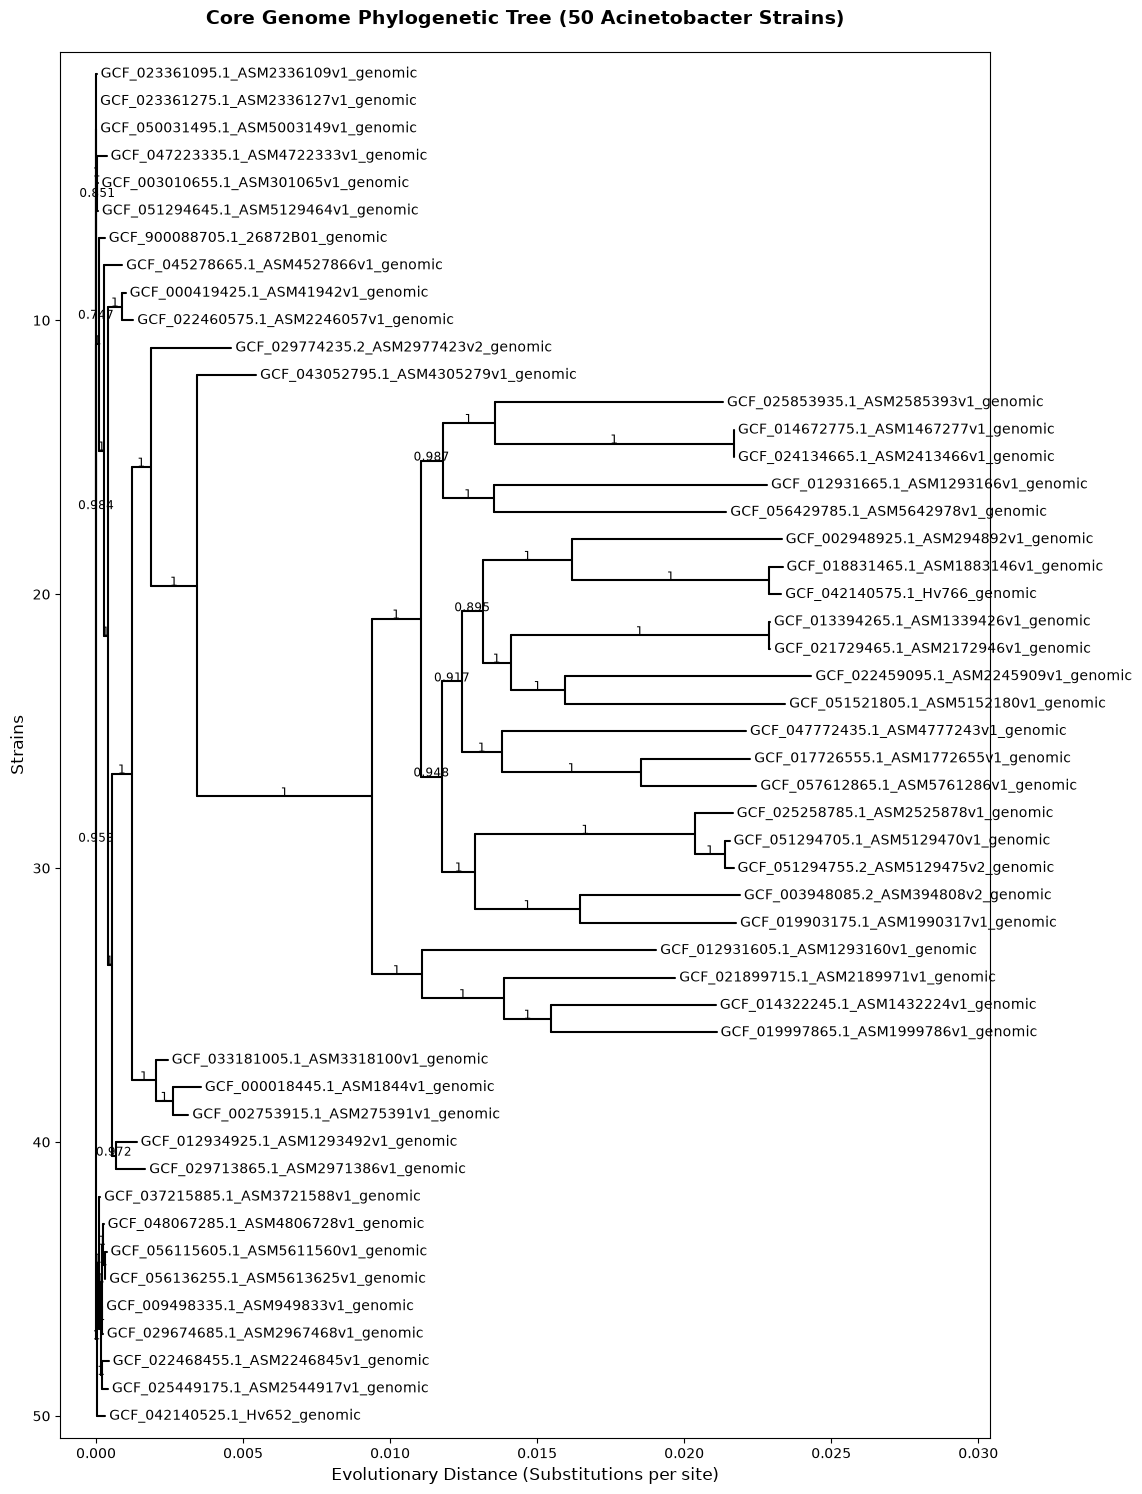

In [2]:
import matplotlib.pyplot as plt
from Bio import Phylo

# 1. Read the core genome tree file in Newick format
tree_file = 'core_genome.tree'
tree = Phylo.read(tree_file, 'newick')

# 2. Configure figure dimensions for 50 strain resolution
fig, ax = plt.subplots(figsize=(12, 18))

# 3. Draw the phylogenetic tree structure
Phylo.draw(tree, do_show=False, axes=ax)

# 4. Format plot title, labels, and layout
plt.title("Core Genome Phylogenetic Tree (50 Acinetobacter Strains)", fontsize=14, fontweight='bold', pad=20)
plt.xlabel("Evolutionary Distance (Substitutions per site)", fontsize=12)
plt.ylabel("Strains", fontsize=12)

# 5. Display output plot
plt.show()

### 📝 Biological Interpretation of the Core Tree

1. **High Lineage Resolution**: The 50 *Acinetobacter* strains separate clearly into distinct clades, supported by high bootstrap/SH-like support values (frequently approaching 1.0).
2. **Clonal Clusters**: Top and bottom clades exhibit near-zero evolutionary distances ($\le 0.001$), indicating tightly conserved clonal lineages likely originating from identical sequence types (STs) or outbreaks.
3. **Evolutionary Divergence**: Middle clade members show greater branch lengths (up to 0.03 substitutions per site), reflecting substantial core genome divergence among those specific lineages.